In [1]:
import numpy as np 
import pandas as pd

In [67]:
df = pd.read_csv("iris.csv")

In [68]:
df1 = df

In [3]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
from sklearn.preprocessing import LabelEncoder

In [5]:
en = LabelEncoder()

In [6]:
df['species'] = en.fit_transform(df['species'])

In [7]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [9]:
df = df[df['species'] != 0][['sepal width (cm)','petal length (cm)','species']]

In [10]:
df.head()

,sepal width (cm),petal length (cm),species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

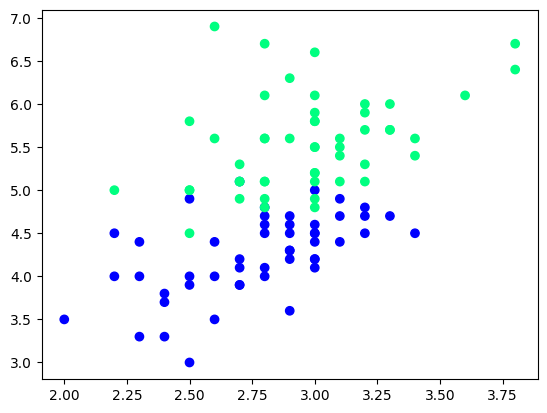

In [12]:
plt.scatter(df['sepal width (cm)'],df['petal length (cm)'],c=df['species'],cmap='winter')

In [13]:
X_train = df.iloc[:60,:].sample(10)
X_train

,sepal width (cm),petal length (cm),species
95,3.0,4.2,1
89,2.5,4.0,1
104,3.0,5.8,2
87,2.3,4.4,1
69,2.5,3.9,1
65,3.1,4.4,1
98,2.5,3.0,1
91,3.0,4.6,1
92,2.6,4.0,1
53,2.3,4.0,1


In [17]:
df = df.sample(100)
X_train = df.iloc[:60,:].sample(10)
y_train = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [18]:
X_train, y_train, df_test

(     sepal width (cm)  petal length (cm)  species
 144               3.3                5.7        2
 112               3.0                5.5        2
 107               2.9                6.3        2
 99                2.8                4.1        1
 100               3.3                6.0        2
 59                2.7                3.9        1
 94                2.7                4.2        1
 106               2.5                4.5        2
 114               2.8                5.1        2
 110               3.2                5.1        2,
      sepal width (cm)  petal length (cm)  species
 116               3.0                5.5        2
 64                2.9                3.6        1
 75                3.0                4.4        1
 129               3.0                5.8        2
 120               3.2                5.7        2,
      sepal width (cm)  petal length (cm)  species
 74                2.9                4.3        1
 108               2.5       

In [19]:
X_test = y_train.iloc[:,0:2].values
y_test = y_train.iloc[:,-1].values

In [21]:
X_test, y_test

(array([[3. , 5.5],
        [2.9, 3.6],
        [3. , 4.4],
        [3. , 5.8],
        [3.2, 5.7]]),
 array([2, 1, 1, 2, 2]))

In [23]:
df_bag = X_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,sepal width (cm),petal length (cm),species
112,3.0,5.5,2
59,2.7,3.9,1
99,2.8,4.1,1
114,2.8,5.1,2
107,2.9,6.3,2
144,3.3,5.7,2
100,3.3,6.0,2
100,3.3,6.0,2


In [24]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [25]:
dt_bag1 = DecisionTreeClassifier()

In [53]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print("accuracy",accuracy_score(y_test,y_pred))

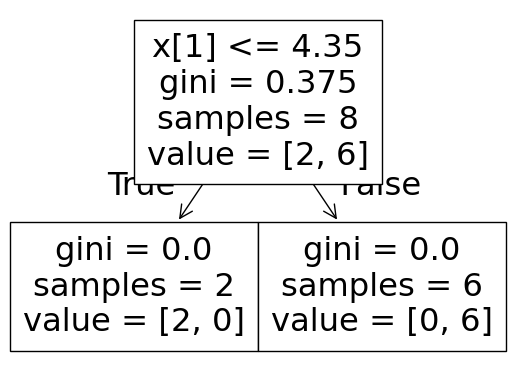

C:\Users\KIIT0001\Downloads\ANACON\envs\ml\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\KIIT0001\Downloads\ANACON\envs\ml\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


accuracy 0.8


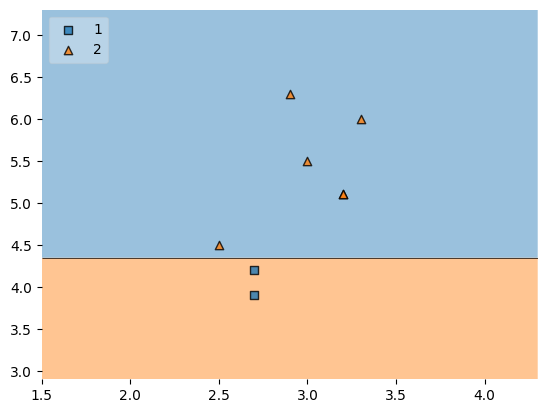

In [54]:
evaluate(dt_bag1,X,y)

In [55]:
df_bag = X_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,sepal width (cm),petal length (cm),species
112,3.0,5.5,2
99,2.8,4.1,1
100,3.3,6.0,2
107,2.9,6.3,2
107,2.9,6.3,2
99,2.8,4.1,1
100,3.3,6.0,2
100,3.3,6.0,2


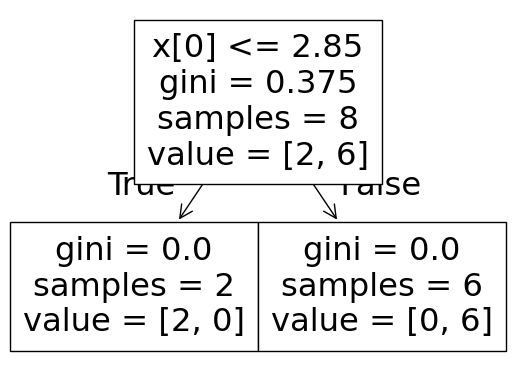

C:\Users\KIIT0001\Downloads\ANACON\envs\ml\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\KIIT0001\Downloads\ANACON\envs\ml\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


accuracy 0.6


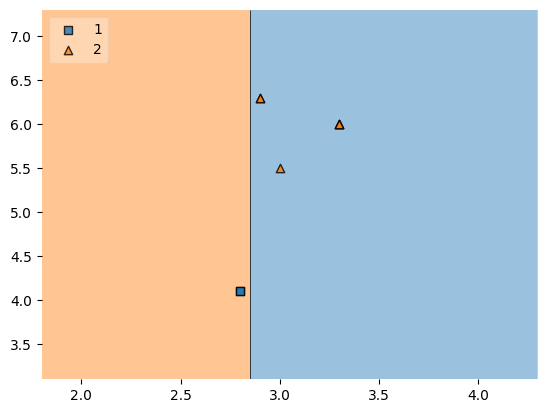

In [56]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [57]:
df_bag = X_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,sepal width (cm),petal length (cm),species
110,3.2,5.1,2
99,2.8,4.1,1
110,3.2,5.1,2
112,3.0,5.5,2
99,2.8,4.1,1
100,3.3,6.0,2
114,2.8,5.1,2
112,3.0,5.5,2


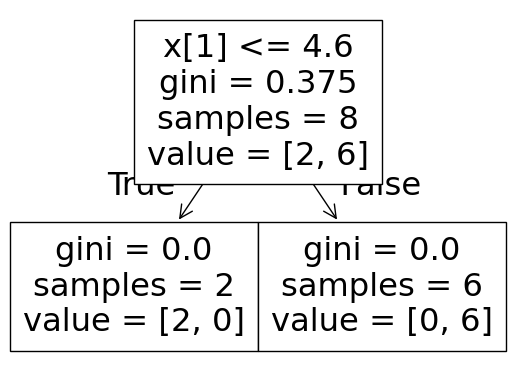

C:\Users\KIIT0001\Downloads\ANACON\envs\ml\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\KIIT0001\Downloads\ANACON\envs\ml\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


accuracy 1.0


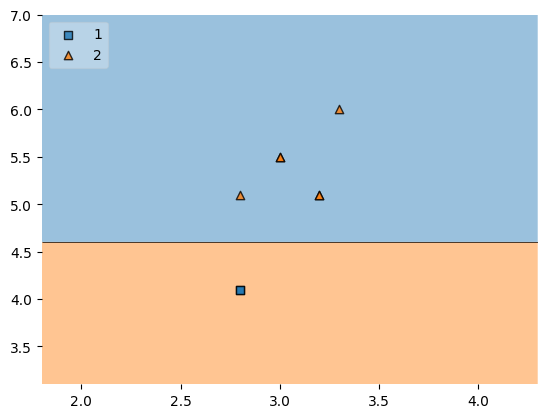

In [58]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

In [59]:
df_test

,sepal width (cm),petal length (cm),species
74,2.9,4.3,1
108,2.5,5.8,2
71,2.8,4.0,1
111,2.7,5.3,2
54,2.8,4.6,1


In [61]:
print("Predictor 1",dt_bag1.predict(np.array([2.8,4.0]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([2.8,4.0]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([2.8,4.0]).reshape(1,2)))

Predictor 1 [1]
Predictor 2 [1]
Predictor 3 [1]


C:\Users\KIIT0001\Downloads\ANACON\envs\ml\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\KIIT0001\Downloads\ANACON\envs\ml\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\KIIT0001\Downloads\ANACON\envs\ml\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [62]:
# Row sampling without replacement
df_train

,sepal width (cm),petal length (cm),species
61,3.0,4.2,1
112,3.0,5.5,2
136,3.4,5.6,2
87,2.3,4.4,1
71,2.8,4.0,1
60,2.0,3.5,1
144,3.3,5.7,2
80,2.4,3.8,1
52,3.1,4.9,1
78,2.9,4.5,1


In [63]:
df_train.sample(8)

,sepal width (cm),petal length (cm),species
71,2.8,4.0,1
52,3.1,4.9,1
61,3.0,4.2,1
80,2.4,3.8,1
78,2.9,4.5,1
136,3.4,5.6,2
87,2.3,4.4,1
144,3.3,5.7,2


In [69]:
df2 = df1.sample(10)

In [70]:
df2

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
74,6.4,2.9,4.3,1.3,versicolor
43,5.0,3.5,1.6,0.6,setosa
131,7.9,3.8,6.4,2.0,virginica
89,5.5,2.5,4.0,1.3,versicolor
14,5.8,4.0,1.2,0.2,setosa
49,5.0,3.3,1.4,0.2,setosa
143,6.8,3.2,5.9,2.3,virginica
39,5.1,3.4,1.5,0.2,setosa
45,4.8,3.0,1.4,0.3,setosa
98,5.1,2.5,3.0,1.1,versicolor


In [77]:
df2.sample(2,replace=True,axis=1)

,petal length (cm),sepal length (cm)
74,4.3,6.4
43,1.6,5.0
131,6.4,7.9
89,4.0,5.5
14,1.2,5.8
49,1.4,5.0
143,5.9,6.8
39,1.5,5.1
45,1.4,4.8
98,3.0,5.1


In [78]:
df1.sample(8,replace=True).sample(2,replace=True,axis=1)

,sepal length (cm),species
83,6.0,versicolor
124,6.7,virginica
128,6.4,virginica
99,5.7,versicolor
57,4.9,versicolor
143,6.8,virginica
61,5.9,versicolor
55,5.7,versicolor
